In [49]:
import pandas as pd

In [50]:
df=pd.read_csv('mall_customers.csv')

In [51]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,41,55,50
1,2,Female,69,51,54
2,3,Female,28,46,48
3,4,Female,66,55,54
4,5,Male,25,28,12


In [52]:
df.shape

(200, 5)

In [53]:
df.duplicated().sum()

0

In [54]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [56]:
df.drop(columns='CustomerID',inplace=True)

In [57]:
num_cols=df.select_dtypes(include='number').columns

<Axes: >

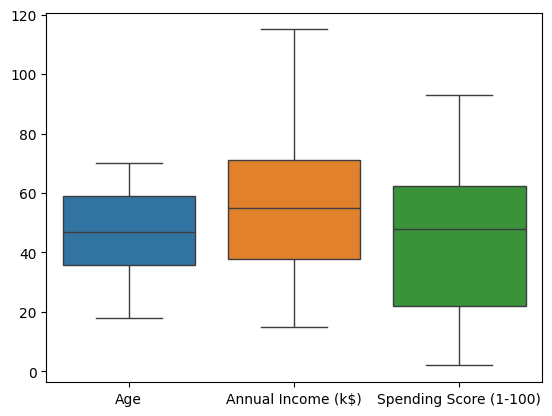

In [58]:
import seaborn as sns
sns.boxplot(df[num_cols])

In [59]:
for col in num_cols:
    Q1= df[col].quantile(.25)
    Q3= df[col].quantile(.75)

    IQR= Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    outliers=df[(df[col]<lower) | (df[col]>upper)]

    print('\n',col)
    print('lower: ',lower)
    print('upper: ',upper)
    print('outliers: ',len(outliers))


 Age
lower:  0.875
upper:  93.875
outliers:  0

 Annual Income (k$)
lower:  -12.125
upper:  120.875
outliers:  0

 Spending Score (1-100)
lower:  -38.375
upper:  122.625
outliers:  0


In [60]:
df['Gender'].value_counts()

Gender
Female    105
Male       95
Name: count, dtype: int64

In [62]:
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [63]:
preprocessor=ColumnTransformer(
    transformers=[
        ('scaling',MinMaxScaler(),num_cols),
        ('encoing',OneHotEncoder(handle_unknown='ignore'),['Gender'])
    ],
    remainder='passthrough'
)

### Elbow method

In [64]:
import matplotlib.pyplot as plt

In [65]:
inertia=[]
for k in range(2,11):
    pipe=Pipeline(
        steps=[
            ('prep',preprocessor),
            ('model',KMeans(n_clusters=k,random_state=42,n_init=10))
        ]
    )
    pipe.fit(df)
    inertia.append(pipe.named_steps['model'].inertia_)

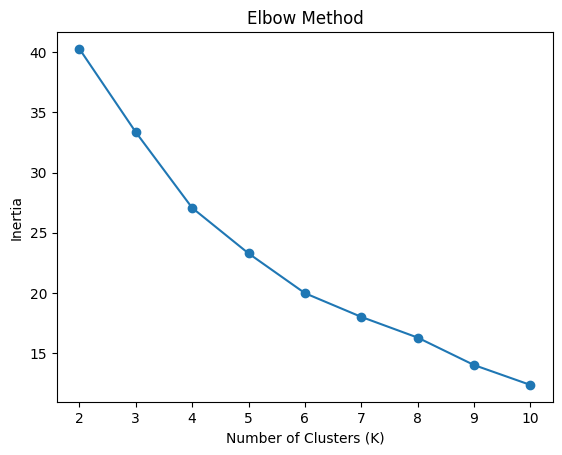

In [66]:
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### silhouette_score

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    pipe=Pipeline(
        steps=[
            ('prep',preprocessor),
            ('model',KMeans(n_clusters=k,random_state=42,n_init=10))
        ]
    )
    labels = pipe.fit_predict(df)
    X_scaled = pipe.named_steps['prep'].transform(df)
    score = silhouette_score(X_scaled,labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.3f}")

K=2, Silhouette Score=0.622
K=3, Silhouette Score=0.473
K=4, Silhouette Score=0.300
K=5, Silhouette Score=0.310
K=6, Silhouette Score=0.316
K=7, Silhouette Score=0.305
K=8, Silhouette Score=0.328
K=9, Silhouette Score=0.366
K=10, Silhouette Score=0.371


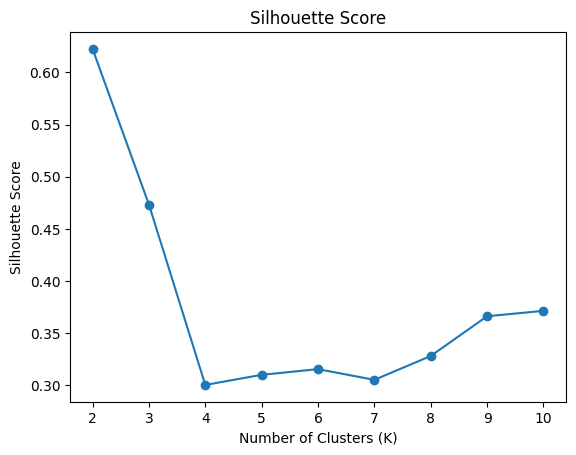

In [68]:
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [69]:
main_pipe=Pipeline(
    steps=[
        ('prep',preprocessor),
        ('model',KMeans(random_state=42,n_clusters=5,n_init=10))
    ]
)

In [70]:
main_pipe.fit(df)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoing', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
df['Cluster']=main_pipe.fit_predict(df)

In [72]:
df['Cluster'].value_counts().sort_index()

Cluster
0    45
1    58
2    32
3    47
4    18
Name: count, dtype: int64

In [75]:
df.groupby('Cluster').mean(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,57.888889,47.844444,36.377778
1,39.068966,61.465517,58.896552
2,29.281250,46.375000,41.625000
3,57.340426,49.085106,29.574468
4,42.222222,83.277778,79.833333
